# Eswatini Drought Monitoring — Real-Data Analysis

Reimplements the calculations from the `index.html` prototype in Python, but driven by **real data** from `resources/`:

| File | Content |
|---|---|
| `cdi_map_2025-07.geojson` | 59 Tinkhundla polygons with official CDI drought categories, July 2025 |
| `step_0303_cdi_pct_rank_eswatini_202507.tiff` | CDI percent-rank raster (44×44, 0.05° ≈ 5.5 km, EPSG:4326), July 2025 |
| `11 11 2025 weather report.txt` | Hourly Davis weather-station log, 30 Oct – 12 Nov 2025 |

Sections:
1. Official CDI drought map (vector)
2. CDI percent-rank raster
3. Zonal statistics + percentile → D-class classification (the core CDI algorithm)
4. Weather-station time series
5. Prototype algorithms ported to Python (Δ-based confidence, modal consensus)
6. Tidy CSV exports

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio
from rasterio.features import geometry_mask
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.patches import Patch

RES = Path('resources')
OUT = Path('data')
OUT.mkdir(exist_ok=True)

GEOJSON_PATH = RES / 'cdi_map_2025-07.geojson'
RASTER_PATH = RES / 'step_0303_cdi_pct_rank_eswatini_202507.tiff'
WEATHER_PATH = RES / '11 11 2025 weather report.txt'

# Drought-category colours = the legacy DROUGHT_CATEGORY_COLOR from eswatini-droughtmap-hub
# (frontend/src/static/config.js) — the system's source of truth for D-class colours.
# Kept as-is (NOT the Figma palette): the category colours pre-date the redesign.
# (DROUGHT_CATEGORY_COLOR also maps -9999 "No Data" -> #ffffff; handled separately below.)
CAT_NAMES = {0: 'Wet/normal', 1: 'D0 Abnormally Dry', 2: 'D1 Moderate', 3: 'D2 Severe', 4: 'D3 Extreme', 5: 'D4 Exceptional'}
CAT_COLORS = {0: '#b9f8cf', 1: '#ffff00', 2: '#fbd47f', 3: '#ffaa00', 4: '#e60000', 5: '#730000'}

## 1. Official CDI drought map — July 2025 (vector)

Each of the 59 Tinkhundla carries a `category` (0 = wet/normal … 5 = D4 Exceptional) assigned by the CDI workflow.

In [2]:
gdf = gpd.read_file(GEOJSON_PATH)
print(f'{len(gdf)} Tinkhundla, CRS: {gdf.crs}')
gdf[['name', 'region', 'category', 'cat_name', 'AGENCY', 'Partner']].head(8)

59 Tinkhundla, CRS: EPSG:4326


,name,region,category,cat_name,AGENCY,Partner
0,Hhukwini,Hhohho,1,D0 Abnormally Dry,ACAT,Nazarene Compassionate Ministries
1,Lobamba,Hhohho,2,D1 Moderate Drought,Bantwana Initiative,Save the Children
2,Madlangempisi,Hhohho,3,D2 Severe Drought,Bantwana Initiative,World Vision Eswatini
3,Mbabane East,Hhohho,2,D1 Moderate Drought,SWAGGA,ACAT
4,Mbabane West,Hhohho,1,D0 Abnormally Dry,SWAGGA,ACAT
5,Mhlangatane,Hhohho,5,D4 Exceptional Drought,SWAGGA,World Vision Eswatini
6,Motshane,Hhohho,2,D1 Moderate Drought,"SWAGGA, Young Heroes",Woman Farmer Foundation
7,Nkhaba,Hhohho,2,D1 Moderate Drought,"Bantwana Initiative, SWAGAA",Woman Farmer Foundation


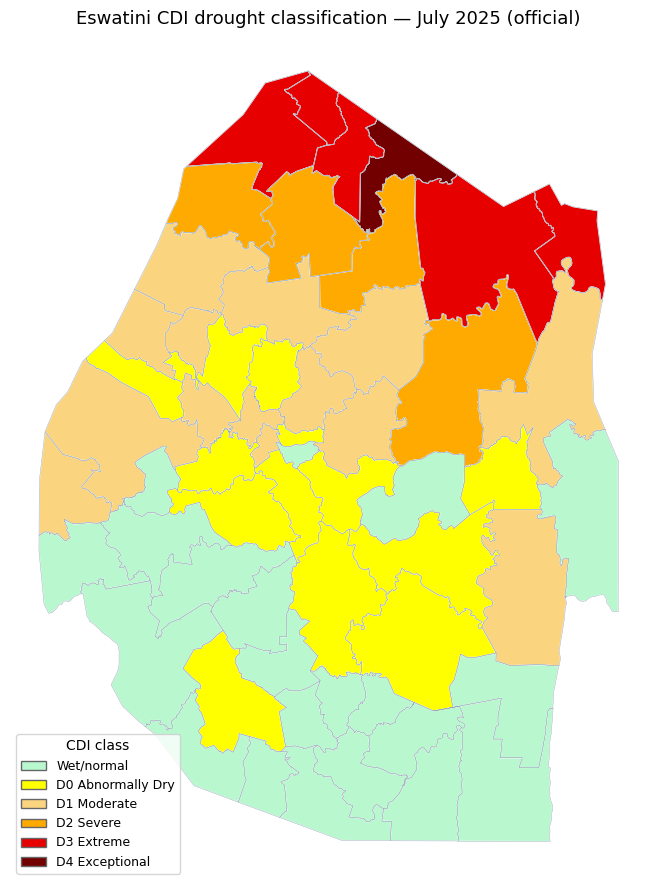

In [3]:
fig, ax = plt.subplots(figsize=(8, 9))
gdf.plot(ax=ax, color=gdf['category'].map(CAT_COLORS), edgecolor='white', linewidth=0.7)
gdf.boundary.plot(ax=ax, color='#94a3b8', linewidth=0.3)
handles = [Patch(facecolor=CAT_COLORS[k], edgecolor='#666', label=CAT_NAMES[k]) for k in sorted(CAT_COLORS)]
ax.legend(handles=handles, loc='lower left', fontsize=9, title='CDI class')
ax.set_title('Eswatini CDI drought classification — July 2025 (official)', fontsize=13)
ax.set_axis_off()
plt.tight_layout()
plt.show()

cat_name,D0 Abnormally Dry,D1 Moderate Drought,D2 Severe Drought,D3 Extreme Drought,D4 Exceptional Drought,Wet/normal conditions
region,,,,,,
Hhohho,3,5,3,3,1,0
Lubombo,3,2,1,2,0,3
Manzini,6,7,0,0,0,5
Shiselweni,2,0,0,0,0,13


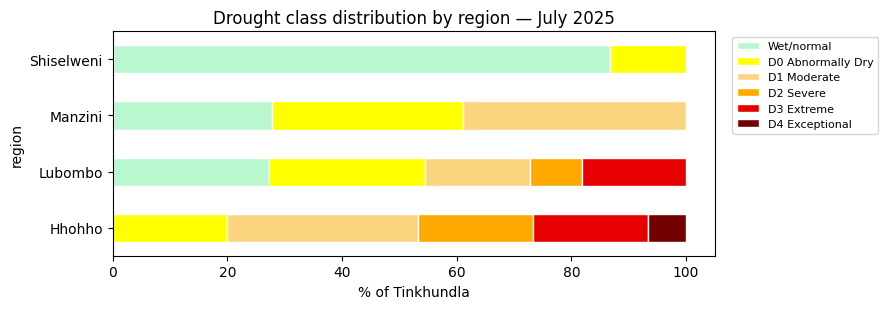

In [4]:
# Regional breakdown — the same calculation behind the prototype's 'Regional breakdown' card
crosstab = pd.crosstab(gdf['region'], gdf['cat_name'])
display(crosstab)

pct = pd.crosstab(gdf['region'], gdf['category'], normalize='index') * 100
ax = pct.plot(kind='barh', stacked=True, figsize=(9, 3.2),
              color=[CAT_COLORS[c] for c in pct.columns], edgecolor='white')
ax.set_xlabel('% of Tinkhundla')
ax.set_title('Drought class distribution by region — July 2025')
ax.legend([CAT_NAMES[c] for c in pct.columns], bbox_to_anchor=(1.02, 1), fontsize=8)
plt.tight_layout()
plt.show()

## 2. CDI percent-rank raster

The GeoTIFF holds the **CDI percent rank** (0–1): where current conditions fall in the historical distribution.
Low percent rank = unusually dry. This is the raw layer the drought classes are derived from.

shape (44, 44), valid pixels 1849, range 0.000–0.692


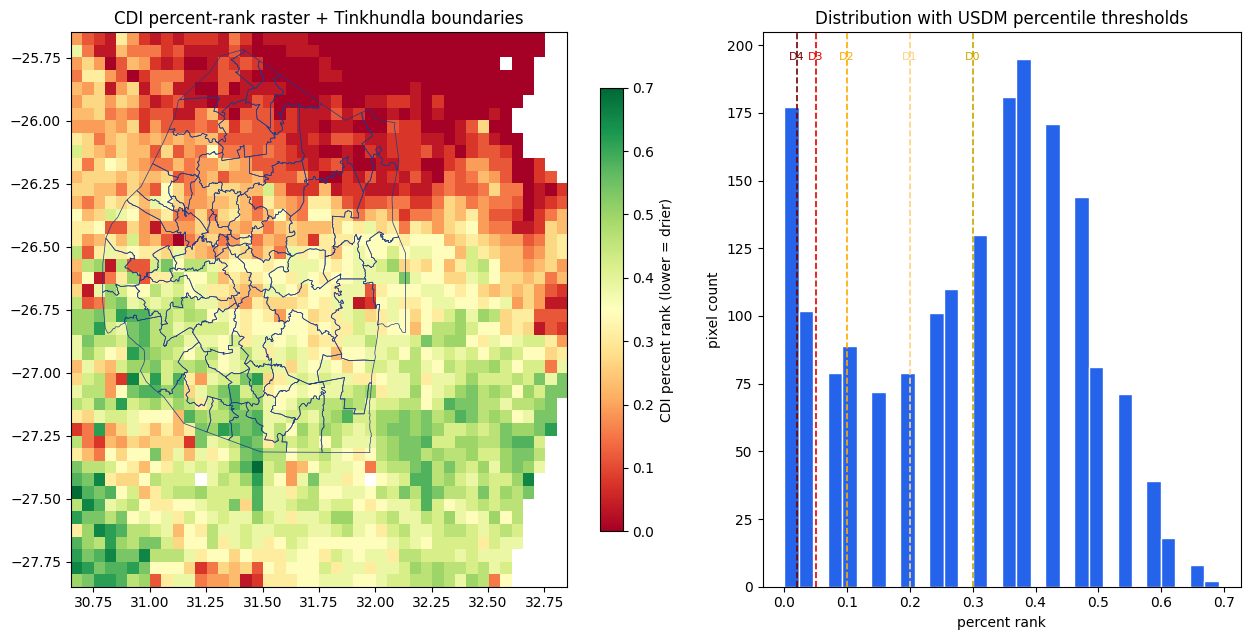

In [5]:
with rasterio.open(RASTER_PATH) as src:
    raster = src.read(1)
    transform = src.transform
    bounds = src.bounds
    raster_crs = src.crs

raster = np.where(raster <= -9990, np.nan, raster)  # -9999 = nodata
valid = raster[~np.isnan(raster)]
print(f'shape {raster.shape}, valid pixels {valid.size}, range {valid.min():.3f}–{valid.max():.3f}')

fig, axes = plt.subplots(1, 2, figsize=(13, 6.5), width_ratios=[1.4, 1])
extent = [bounds.left, bounds.right, bounds.bottom, bounds.top]
im = axes[0].imshow(raster, extent=extent, cmap='RdYlGn', vmin=0, vmax=0.7)
gdf.boundary.plot(ax=axes[0], color='#1e3a8a', linewidth=0.5)
plt.colorbar(im, ax=axes[0], shrink=0.8, label='CDI percent rank (lower = drier)')
axes[0].set_title('CDI percent-rank raster + Tinkhundla boundaries')

axes[1].hist(valid, bins=30, color='#2563eb', edgecolor='white')
for thr, lbl, col in [(0.02, 'D4', '#730000'), (0.05, 'D3', '#e60000'), (0.10, 'D2', '#ffaa00'), (0.20, 'D1', '#fcd37f'), (0.30, 'D0', '#caa800')]:
    axes[1].axvline(thr, color=col, linestyle='--', linewidth=1.2)
    axes[1].text(thr, axes[1].get_ylim()[1] * 0.95, lbl, color=col, fontsize=8, ha='center')
axes[1].set_xlabel('percent rank')
axes[1].set_ylabel('pixel count')
axes[1].set_title('Distribution with USDM percentile thresholds')
plt.tight_layout()
plt.show()

## 3. The core CDI algorithm: zonal statistics → percentile classification

This is the calculation the prototype only *mocked*. With real data we can run it:

1. **Zonal mean** — average the percent-rank pixels inside each Inkhundla polygon.
2. **Percentile → D-class** using the standard US Drought Monitor convention:

| Percent rank | Class |
|---|---|
| ≤ 0.02 | D4 Exceptional |
| ≤ 0.05 | D3 Extreme |
| ≤ 0.10 | D2 Severe |
| ≤ 0.20 | D1 Moderate |
| ≤ 0.30 | D0 Abnormally dry |
| > 0.30 | Wet/normal |

3. Compare the derived class with the official `category` in the GeoJSON — the same *satellite × validated* agreement idea the prototype shows.

In [6]:
def zonal_mean(geom, data: np.ndarray, transform) -> float:
    """Mean of valid raster pixels touching the polygon."""
    mask = geometry_mask([geom.__geo_interface__], out_shape=data.shape,
                         transform=transform, invert=True, all_touched=True)
    vals = data[mask]
    vals = vals[~np.isnan(vals)]
    return float(vals.mean()) if vals.size else np.nan


def classify_percent_rank(pr: float) -> int:
    """USDM percentile thresholds → category code (0=wet/normal … 5=D4)."""
    if np.isnan(pr):
        return -1
    if pr <= 0.02:
        return 5
    if pr <= 0.05:
        return 4
    if pr <= 0.10:
        return 3
    if pr <= 0.20:
        return 2
    if pr <= 0.30:
        return 1
    return 0


gdf['pct_rank_mean'] = [zonal_mean(g, raster, transform) for g in gdf.geometry]
gdf['derived_category'] = gdf['pct_rank_mean'].apply(classify_percent_rank)
gdf['delta'] = gdf['derived_category'] - gdf['category']

agree = (gdf['delta'] == 0).mean() * 100
within1 = (gdf['delta'].abs() <= 1).mean() * 100
print(f'Exact agreement derived vs official: {agree:.0f}%  ·  within ±1 class: {within1:.0f}%')
gdf[['name', 'region', 'pct_rank_mean', 'derived_category', 'category', 'cat_name', 'delta']].sort_values('pct_rank_mean').head(12)

Exact agreement derived vs official: 56%  ·  within ±1 class: 97%


,name,region,pct_rank_mean,derived_category,category,cat_name,delta
5,Mhlangatane,Hhohho,0.036476,4,5,D4 Exceptional Drought,-1
29,Lomahasha,Lubombo,0.042200,4,4,D3 Extreme Drought,0
27,Mhlume,Lubombo,0.047435,4,4,D3 Extreme Drought,0
34,Mayiwane,Hhohho,0.054059,3,4,D3 Extreme Drought,-1
36,Timphisini,Hhohho,0.054250,3,4,D3 Extreme Drought,-1
8,Ntfonjeni,Hhohho,0.059519,3,4,D3 Extreme Drought,-1
2,Madlangempisi,Hhohho,0.089107,3,3,D2 Severe Drought,0
35,Ndzingeni,Hhohho,0.123464,2,3,D2 Severe Drought,-1
9,Piggs Peak,Hhohho,0.124381,2,3,D2 Severe Drought,-1
14,Mkhiweni,Manzini,0.176593,2,2,D1 Moderate Drought,0


derived from raster,D0 Abnormally Dry,D1 Moderate,D2 Severe,D3 Extreme,Wet/normal
official,,,,,
D0 Abnormally Dry,7,0,0,0,7
D1 Moderate,9,3,0,0,2
D2 Severe,0,3,1,0,0
D3 Extreme,0,0,3,2,0
D4 Exceptional,0,0,0,1,0
Wet/normal,1,0,0,0,20


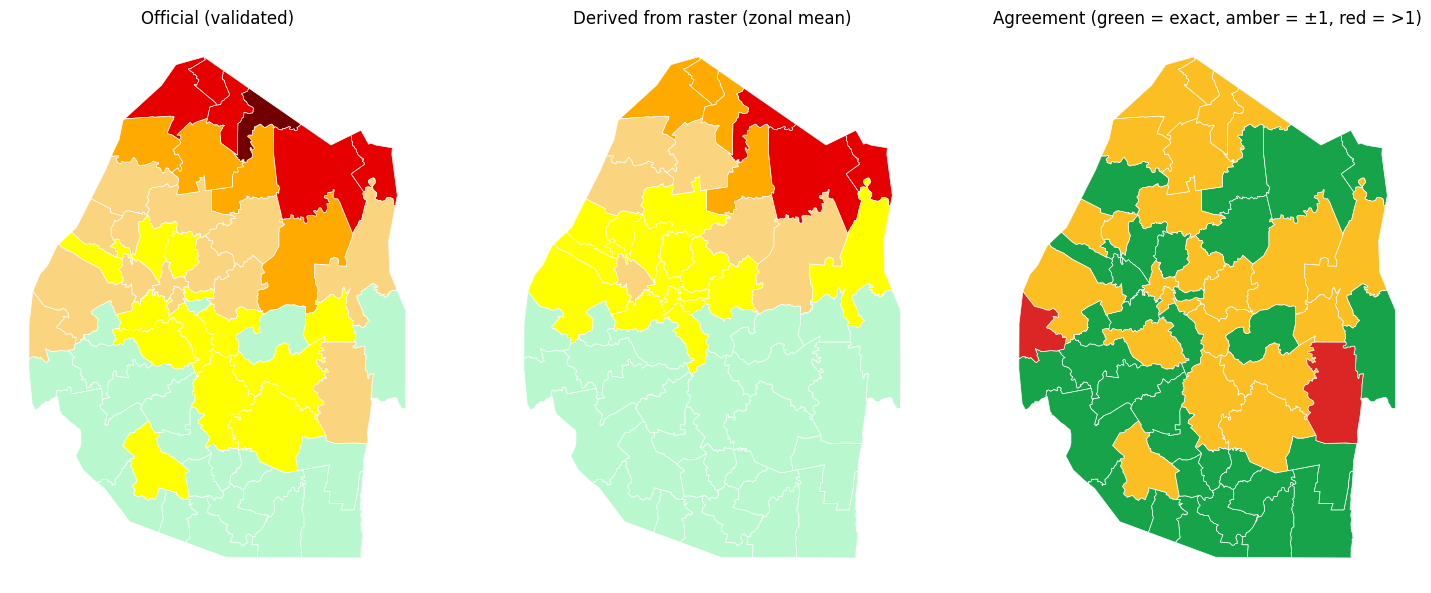

In [7]:
# Confusion matrix official vs derived — where and how far do they diverge?
cm = pd.crosstab(gdf['category'].map(CAT_NAMES).rename('official'),
                 gdf['derived_category'].map(CAT_NAMES).rename('derived from raster'))
display(cm)

fig, axes = plt.subplots(1, 3, figsize=(15, 6))
for ax, col, title in [(axes[0], 'category', 'Official (validated)'),
                       (axes[1], 'derived_category', 'Derived from raster (zonal mean)')]:
    gdf.plot(ax=ax, color=gdf[col].map(CAT_COLORS).fillna('#cccccc'), edgecolor='white', linewidth=0.5)
    ax.set_title(title)
    ax.set_axis_off()

delta_colors = gdf['delta'].map(lambda d: '#16a34a' if d == 0 else ('#fbbf24' if abs(d) == 1 else '#dc2626'))
gdf.plot(ax=axes[2], color=delta_colors, edgecolor='white', linewidth=0.5)
axes[2].set_title('Agreement (green = exact, amber = ±1, red = >1)')
axes[2].set_axis_off()
plt.tight_layout()
plt.show()

## 4. Weather-station time series

Hourly Davis station export, 30 Oct – 12 Nov 2025. The rows are not chronologically sorted in the file, so we parse and sort. This is the kind of in-situ record that anchors the *station* side of the satellite × station comparison.

In [8]:
WEATHER_COLS = [
    'date', 'time', 'temp_out', 'temp_hi', 'temp_low', 'hum_out', 'dew_pt',
    'wind_speed', 'wind_dir', 'wind_run', 'wind_hi_speed', 'wind_hi_dir',
    'wind_chill', 'heat_index', 'thw_index', 'bar', 'rain', 'rain_rate',
    'heat_dd', 'cool_dd', 'temp_in', 'hum_in', 'dew_in', 'heat_in',
    'emc_in', 'air_density_in', 'wind_samp', 'wind_tx', 'iss_recept', 'arc_int',
]

wx = pd.read_csv(WEATHER_PATH, sep='\t', skiprows=2, names=WEATHER_COLS, na_values=['---'])
wx['datetime'] = pd.to_datetime(
    wx['date'] + ' ' + wx['time'].str.replace(' a', ' AM', regex=False).str.replace(' p', ' PM', regex=False),
    format='%d/%m/%y %I:%M %p',
)
wx = wx.sort_values('datetime').reset_index(drop=True)
num_cols = [c for c in WEATHER_COLS if c not in ('date', 'time', 'wind_dir', 'wind_hi_dir')]
wx[num_cols] = wx[num_cols].apply(pd.to_numeric, errors='coerce')
print(f'{len(wx)} hourly records, {wx.datetime.min()} → {wx.datetime.max()}')
wx[['datetime', 'temp_out', 'hum_out', 'dew_pt', 'wind_speed', 'bar', 'rain']].head()

612 hourly records, 2025-10-30 12:51:00 → 2025-11-12 09:00:00


,datetime,temp_out,hum_out,dew_pt,wind_speed,bar,rain
0,2025-10-30 12:51:00,22.1,74.0,17.2,1.8,1013.2,0.0
1,2025-10-30 12:52:00,22.0,74.0,17.2,2.2,1013.2,0.0
2,2025-10-30 12:53:00,22.0,74.0,17.2,2.2,1013.2,0.0
3,2025-10-30 12:54:00,21.9,75.0,17.3,2.2,1013.2,0.0
4,2025-10-30 12:55:00,21.9,75.0,17.3,3.6,1013.2,0.0


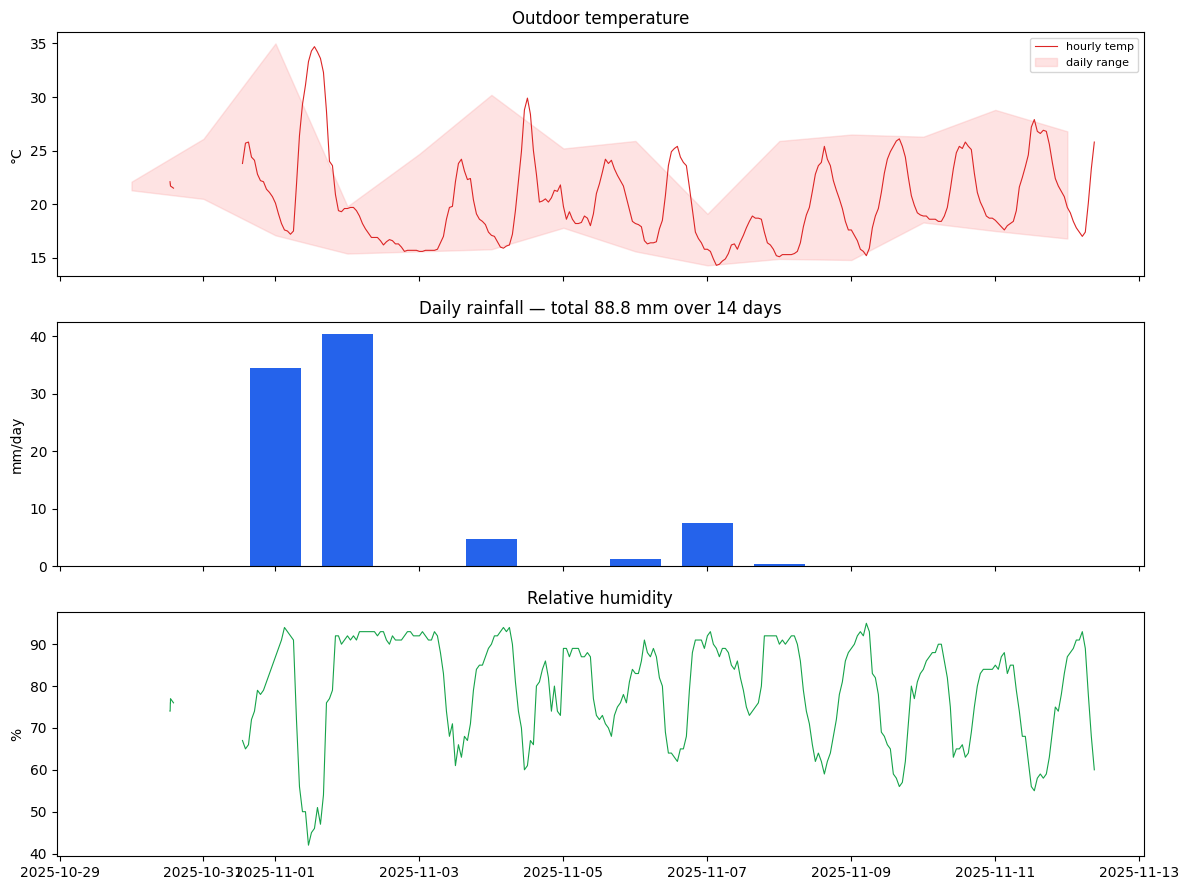

,temp_mean,temp_max,temp_min,rain_total,hum_mean,wind_mean
datetime,,,,,,
2025-10-30,21.85,22.1,21.3,0.0,75.27,1.27
2025-10-31,23.10,26.1,20.5,0.0,75.36,0.97
2025-11-01,24.84,35.0,17.1,34.4,72.49,0.98
2025-11-02,17.12,19.8,15.4,40.4,92.08,0.52
2025-11-03,18.80,24.7,15.6,0.0,80.54,0.71
2025-11-04,20.81,30.2,15.8,4.8,80.46,0.71
2025-11-05,20.50,25.2,17.8,0.0,80.33,0.60
2025-11-06,19.66,25.9,15.6,1.2,79.38,1.03
2025-11-07,16.42,19.1,14.3,7.6,85.25,0.65


In [9]:
daily = wx.set_index('datetime').resample('D').agg(
    temp_mean=('temp_out', 'mean'), temp_max=('temp_hi', 'max'), temp_min=('temp_low', 'min'),
    rain_total=('rain', 'sum'), hum_mean=('hum_out', 'mean'), wind_mean=('wind_speed', 'mean'),
)

fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)
axes[0].plot(wx['datetime'], wx['temp_out'], color='#dc2626', linewidth=0.8, label='hourly temp')
axes[0].fill_between(daily.index, daily['temp_min'], daily['temp_max'], color='#fca5a5', alpha=0.3, label='daily range')
axes[0].set_ylabel('°C')
axes[0].legend(fontsize=8)
axes[0].set_title('Outdoor temperature')

axes[1].bar(daily.index, daily['rain_total'], color='#2563eb', width=0.7)
axes[1].set_ylabel('mm/day')
axes[1].set_title(f'Daily rainfall — total {daily.rain_total.sum():.1f} mm over {len(daily)} days')

axes[2].plot(wx['datetime'], wx['hum_out'], color='#16a34a', linewidth=0.8)
axes[2].set_ylabel('%')
axes[2].set_title('Relative humidity')
plt.tight_layout()
plt.show()
daily.round(2)

## 5. Prototype algorithms ported to Python

Two formulas from `index.html` that operate *on top of* data like the above:

**Δ-based review confidence** (`_rvDeltaConfidence`): `combined = |ΔSPI| + |ΔLST| / 2`, banded into a 1–5 score.
Here we feed it the real disagreement between the raster-derived class and the official class (as a class-unit delta).

**Modal consensus** (`vqConsensus`): consensus % = occurrences of the modal vote ÷ number of submitted votes.

In [10]:
from collections import Counter


def delta_confidence(spi_delta: float, lst_delta: float = 0.0) -> int:
    """Port of _rvDeltaConfidence: weighted |deltas| banded into a 1-5 score."""
    combined = abs(spi_delta) + abs(lst_delta) / 2
    if combined < 0.30:
        return 5
    if combined < 0.60:
        return 4
    if combined < 1.00:
        return 3
    if combined < 1.50:
        return 2
    return 1


def consensus(votes: list) -> tuple:
    """Port of modal()/vqConsensus: (majority value, consensus %)."""
    if not votes:
        return None, 0
    value, count = Counter(votes).most_common(1)[0]
    return value, round(count / len(votes) * 100)


# Confidence from the real satellite-vs-official class deltas (0.5 class units per Δ step)
gdf['confidence'] = (gdf['delta'].abs() * 0.5).apply(delta_confidence)
print('Confidence score distribution (5 = sources strongly agree):')
print(gdf['confidence'].value_counts().sort_index(ascending=False).to_string())

# The prototype's bulk-accept rule: confidence >= 4 can be auto-accepted
auto = gdf[gdf['confidence'] >= 4]
review = gdf[gdf['confidence'] < 4]
print(f'\nBulk-accept eligible: {len(auto)} Tinkhundla · needs human review: {len(review)}')
print('Needs review:', ', '.join(review['name'].tolist()) or '—')

# Consensus demo: votes = [official class, derived class] per region (one 'reviewer' each)
for region, grp in gdf.groupby('region'):
    votes = grp['category'].tolist()
    val, pct = consensus(votes)
    print(f'{region:>11}: modal class {CAT_NAMES[val]:<18} consensus {pct}% across {len(votes)} Tinkhundla')

Confidence score distribution (5 = sources strongly agree):
confidence
5    33
4    24
2     2

Bulk-accept eligible: 57 Tinkhundla · needs human review: 2
Needs review: Mangcongco, Nkilongo
     Hhohho: modal class D1 Moderate        consensus 33% across 15 Tinkhundla
    Lubombo: modal class Wet/normal         consensus 27% across 11 Tinkhundla
    Manzini: modal class D1 Moderate        consensus 39% across 18 Tinkhundla
 Shiselweni: modal class Wet/normal         consensus 87% across 15 Tinkhundla


## 6. Tidy CSV / JSON exports

Flat tables written to `data/` for use in any other tool.

In [11]:
cdi_table = gdf.drop(columns='geometry')[
    ['name', 'region', 'INKHUNDLA', 'AGENCY', 'Partner', 'category', 'cat_name',
     'pct_rank_mean', 'derived_category', 'delta', 'confidence']
].round({'pct_rank_mean': 4})
cdi_table.to_csv(OUT / 'cdi_tinkhundla_2025-07.csv', index=False)

wx.drop(columns=['date', 'time']).to_csv(OUT / 'weather_hourly.csv', index=False)
daily.round(2).to_csv(OUT / 'weather_daily.csv')

for f in sorted(OUT.iterdir()):
    print(f'{f}  ({f.stat().st_size / 1024:.1f} KB)')

data/cdi_tinkhundla_2025-07.csv  (5.4 KB)
data/iks_kobo_catalogue.csv  (3.0 KB)
data/iks_kobo_submissions_long.csv  (139.3 KB)
data/prototype  (4.0 KB)
data/weather_daily.csv  (0.6 KB)
data/weather_hourly.csv  (89.1 KB)


## Summary

- The **percentile-rank → D-class** classification (the real CDI algorithm the prototype mocks) runs end-to-end on the July 2025 raster, and its zonal output can be compared directly with the official validated map.
- The prototype's **Δ-based confidence score** and **modal consensus** formulas port to ~20 lines of Python and work unchanged on real deltas.
- The weather-station log parses cleanly and provides the in-situ side for future satellite × station agreement checks (SPI would need a longer rainfall record — ≥30 years — to fit the climatology).
- Flat CSVs are exported to `data/` for reuse.